<a href="https://colab.research.google.com/github/edumabagraham/uropatch-data-analysis/blob/real_world_implementation/TabPfn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# install tabpfn
!pip install tabpfn

In [17]:
!git clone -b real_world_implementation https://github.com/edumabagraham/uropatch-data-analysis.git

Cloning into 'uropatch-data-analysis'...
remote: Enumerating objects: 8016, done.
remote: Counting objects: 100% (35/35), done.
remote: Compressing objects: 100% (29/29), done.
remote: Total 8016 (delta 7), reused 19 (delta 6), pack-reused 7981 (from 3)
Receiving objects: 100% (8016/8016), 335.15 MiB | 2.84 MiB/s, done.
Resolving deltas: 100% (1115/1115), done.
Updating files: 100% (1208/1208), done.


In [18]:
%cd uropatch-data-analysis

/content/uropatch-data-analysis/uropatch-data-analysis


In [19]:
import os
import pickle
# import mlflow
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
import plotly.express as px
# import scikit_posthocs as sp
import matplotlib.pyplot as plt

from tqdm import tqdm
from numpy import sort
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import cross_val_score
# from mlflow.models.signature import infer_signature
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectFromModel
from sklearn.preprocessing import scale, StandardScaler
from sklearn.model_selection import GroupKFold, GroupShuffleSplit
from xgboost import XGBClassifier, plot_importance, XGBRFClassifier
from sklearn.linear_model import LogisticRegression
from scipy.stats import friedmanchisquare
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score, roc_auc_score
from sklearn.metrics import make_scorer, accuracy_score, precision_score, recall_score, f1_score
import torch
# from aeon.visualisation import plot_critical_difference


In [21]:
features = pd.read_csv('improved_features_data_main/two_class_raw_5s_yo_0.8.csv')

features.drop(['center_time', 'start_time', 'end_time'], axis= 1, inplace=True)
features
# features.columns

,acc_x_permutation_entropy,acc_x_spectral_entropy,acc_x_mean,acc_x_std,acc_x_range,acc_x_rms,acc_x_var,acc_x_min,acc_x_max,acc_x_time_energy,...,gyr_mag_spectral_centroid,gyr_mag_spectral_spread,gyr_mag_spectral_flatness,gyr_mag_peak_frequency_ratio,gyr_mag_hjorth_frequency,gyr_mag_spectral_skewness,gyr_mag_spectral_kurtosis,gyr_mag_snr,label,experiment_id
0,0.888117,0.737073,0.833686,0.688622,5.349532,1.081311,0.474200,-1.100002,4.249530,344.923696,...,1.617072,2.350395,0.024553,0.404284,8.245249,3.127276,19.880895,-1.683529,non-void,1
1,0.903643,0.831037,0.669089,0.585473,4.363070,0.889078,0.342779,-1.100002,3.263068,233.185482,...,2.222707,3.726635,0.084080,0.403024,9.043875,2.993030,13.751198,-1.706252,non-void,1
2,0.908870,0.749159,0.646192,0.548827,3.840626,0.847806,0.301211,-0.876123,2.964503,212.038819,...,3.681019,4.372275,0.134324,0.119460,11.457835,1.949541,7.037544,-8.675283,non-void,1
3,0.907880,0.743695,0.628383,0.661715,5.457410,0.912541,0.437867,-2.492907,2.964503,245.655723,...,1.930021,2.955711,0.056641,0.238822,11.040642,3.624378,20.095024,-5.034129,non-void,1
4,0.908219,0.746226,0.612415,0.656816,5.457410,0.898031,0.431407,-2.492907,2.964503,237.905625,...,2.507182,3.363227,0.079969,0.167024,10.688664,3.083834,15.269799,-6.978540,non-void,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2263,0.900708,0.758239,0.214183,0.608492,1.740192,0.645087,0.370263,-0.690615,1.049576,125.673411,...,2.172779,4.093742,0.082154,0.351920,13.562826,3.083161,13.418745,-2.651838,non-void,41
2264,0.903151,0.759127,-0.038777,0.594069,1.849070,0.595333,0.352918,-0.799493,1.049576,107.035411,...,1.296142,2.979989,0.036163,0.329950,13.282788,4.759630,28.256881,-3.076588,non-void,41
2265,0.906503,0.667884,-0.261329,0.392532,1.674563,0.471566,0.154082,-0.799493,0.875070,67.157030,...,1.708962,4.231361,0.062594,0.525947,13.365424,3.735215,17.151238,0.451154,non-void,41
2266,0.905755,0.893204,-0.398670,0.158961,0.758337,0.429193,0.025269,-0.799493,-0.041157,55.630382,...,3.577870,5.411444,0.139663,0.163480,13.666432,2.187064,7.200026,-7.090101,non-void,41


In [22]:
X = features.drop(columns=['label', 'experiment_id'])
y = features['label']
groups = features['experiment_id']

# Split the data into training and testing sets
splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(splitter.split(X, y, groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

groups_train, groups_test = groups.iloc[train_idx], groups.iloc[test_idx]

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (confusion_matrix, classification_report,
                             accuracy_score, precision_score, recall_score, f1_score)
from sklearn.preprocessing import LabelEncoder
from tabpfn import TabPFNClassifier
import torch

# 1. Encode labels (if needed)
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

# 2. Train TabPFN
classifier = TabPFNClassifier(device='cuda' if torch.cuda.is_available() else 'cpu')
classifier.fit(X_train, y_train_encoded)

# 3. Predict
y_pred_encoded = classifier.predict(X_test)
y_pred = le.inverse_transform(y_pred_encoded)  # Convert back to original labels



In [26]:
classes = ['void', 'non-void']

=== Classification Report ===
              precision    recall  f1-score   support

        void       0.73      0.32      0.45       246
    non-void       0.67      0.92      0.77       364

    accuracy                           0.68       610
   macro avg       0.70      0.62      0.61       610
weighted avg       0.69      0.68      0.64       610


=== Key Metrics ===
Accuracy: 0.6787
Precision (macro avg): 0.6994
Recall (macro avg): 0.6207
F1-Score (macro avg): 0.6100


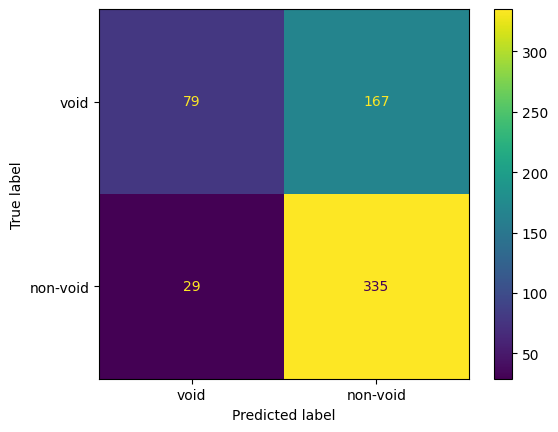

In [29]:
# 4. Generate Metrics
print("=== Classification Report ===")
print(classification_report(y_test, y_pred, labels=classes))

print("\n=== Key Metrics ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision (macro avg): {precision_score(y_test, y_pred, average='macro'):.4f}")
print(f"Recall (macro avg): {recall_score(y_test, y_pred, average='macro'):.4f}")
print(f"F1-Score (macro avg): {f1_score(y_test, y_pred, average='macro'):.4f}")

# # 5. Confusion Matrix Visualization
# def plot_confusion_matrix(y_true, y_pred, classes):
#     cm = confusion_matrix(y_true, y_pred, labels=classes)
#     plt.figure(figsize=(8, 6))
#     plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
#     plt.title("5s 0.8 overlap")
#     plt.colorbar()
#     tick_marks = np.arange(len(classes))
#     plt.xticks(tick_marks, classes, rotation=45)
#     plt.yticks(tick_marks, classes)

#     # Add text annotations
#     thresh = cm.max() / 2.
#     for i in range(cm.shape[0]):
#         for j in range(cm.shape[1]):
#             plt.text(j, i, format(cm[i, j], 'd'),
#                      horizontalalignment="center",
#                      color="white" if cm[i, j] > thresh else "black")

#     plt.ylabel('True label')
#     plt.xlabel('Predicted label')
#     plt.tight_layout()
#     plt.show()

# plot_confusion_matrix(y_test, y_pred, classes=classes)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=classes)
cm_display = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = classes)
cm_display.plot()
plt.show()

Test TabPFN with correctly normalized data

In [37]:
train_path = 'deployable/data/extracted_features_data/2_class/train_set/two_class_5s_0.8.csv'
test_path = 'deployable/data/extracted_features_data/2_class/test_set/two_class_5s_0.8.csv'

train_data = pd.read_csv(train_path)
test_data = pd.read_csv(test_path)


train_data.drop(['center_time', 'start_time', 'end_time'], axis= 1, inplace=True)
test_data.drop(['center_time', 'start_time', 'end_time'], axis= 1, inplace=True)

X_train = train_data.drop(columns=['label', 'experiment_id'])
y_train = train_data['label']

X_test = test_data.drop(columns=['label', 'experiment_id'])
y_test = test_data['label']

In [38]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (confusion_matrix, classification_report,
                             accuracy_score, precision_score, recall_score, f1_score)
from sklearn.preprocessing import LabelEncoder
from tabpfn import TabPFNClassifier
import torch

# 1. Encode labels (if needed)
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

# 2. Train TabPFN
classifier = TabPFNClassifier(device='cuda' if torch.cuda.is_available() else 'cpu')
classifier.fit(X_train, y_train_encoded)

# 3. Predict
y_pred_encoded = classifier.predict(X_test)
y_pred = le.inverse_transform(y_pred_encoded)  # Convert back to original labels

=== Classification Report ===
              precision    recall  f1-score   support

        void       0.78      0.37      0.50       244
    non-void       0.69      0.93      0.79       361

    accuracy                           0.70       605
   macro avg       0.73      0.65      0.65       605
weighted avg       0.72      0.70      0.67       605


=== Key Metrics ===
Accuracy: 0.7041
Precision (macro avg): 0.7342
Recall (macro avg): 0.6498
F1-Score (macro avg): 0.6455


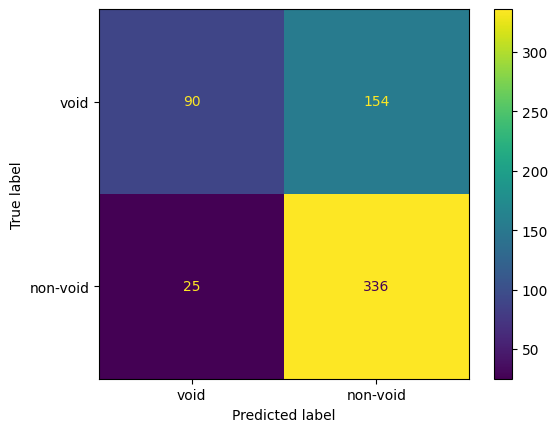

In [39]:
# 4. Generate Metrics
print("=== Classification Report ===")
print(classification_report(y_test, y_pred, labels=classes))

print("\n=== Key Metrics ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision (macro avg): {precision_score(y_test, y_pred, average='macro'):.4f}")
print(f"Recall (macro avg): {recall_score(y_test, y_pred, average='macro'):.4f}")
print(f"F1-Score (macro avg): {f1_score(y_test, y_pred, average='macro'):.4f}")


# Confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=classes)
cm_display = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = classes)
cm_display.plot()
plt.show()

The accuracy is being skewed by the metrics of the non-void class

## Multiclass classification

In [40]:
train_path = 'deployable/data/extracted_features_data/3_class/train_set/two_class_5s_0.8.csv'
test_path = 'deployable/data/extracted_features_data/3_class/test_set/two_class_5s_0.8.csv'

train_data = pd.read_csv(train_path)
test_data = pd.read_csv(test_path)


train_data.drop(['center_time', 'start_time', 'end_time'], axis= 1, inplace=True)
test_data.drop(['center_time', 'start_time', 'end_time'], axis= 1, inplace=True)

X_train = train_data.drop(columns=['label', 'experiment_id'])
y_train = train_data['label']

X_test = test_data.drop(columns=['label', 'experiment_id'])
y_test = test_data['label']

In [41]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (confusion_matrix, classification_report,
                             accuracy_score, precision_score, recall_score, f1_score)
from sklearn.preprocessing import LabelEncoder
from tabpfn import TabPFNClassifier
import torch

# 1. Encode labels (if needed)
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

# 2. Train TabPFN
classifier = TabPFNClassifier(device='cuda' if torch.cuda.is_available() else 'cpu')
classifier.fit(X_train, y_train_encoded)

# 3. Predict
y_pred_encoded = classifier.predict(X_test)
y_pred = le.inverse_transform(y_pred_encoded)  # Convert back to original labels

In [46]:
classes = ['pre-void', 'void', 'post-void']

=== Classification Report ===
              precision    recall  f1-score   support

    pre-void       0.36      0.63      0.46       103
        void       0.75      0.55      0.63       244
   post-void       0.62      0.59      0.60       258

    accuracy                           0.58       605
   macro avg       0.57      0.59      0.56       605
weighted avg       0.63      0.58      0.59       605


=== Key Metrics ===
Accuracy: 0.5785
Precision (macro avg): 0.5747
Recall (macro avg): 0.5884
F1-Score (macro avg): 0.5638


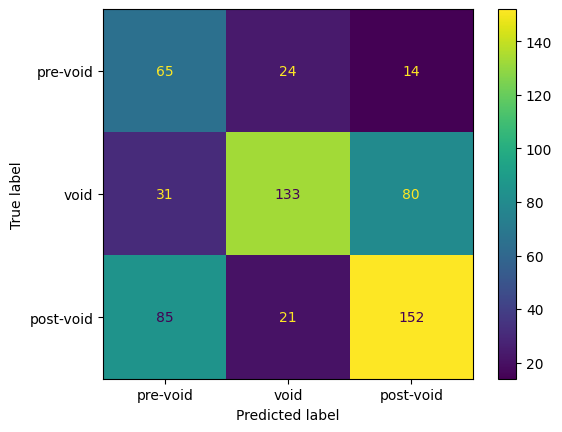

In [47]:
# 4. Generate Metrics
print("=== Classification Report ===")
print(classification_report(y_test, y_pred, labels=classes))

print("\n=== Key Metrics ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision (macro avg): {precision_score(y_test, y_pred, average='macro'):.4f}")
print(f"Recall (macro avg): {recall_score(y_test, y_pred, average='macro'):.4f}")
print(f"F1-Score (macro avg): {f1_score(y_test, y_pred, average='macro'):.4f}")


# Confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=classes)
cm_display = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = classes)
cm_display.plot()
plt.show()

In [ ]:
# label_encoder = LabelEncoder()
# # Encode y_test and y_train
# y_train_encoded = label_encoder.fit_transform(y_train)
# y_test_encoded = label_encoder.transform(y_test)

In [ ]:
# from sklearn.metrics import accuracy_score, f1_score

# # Predict on training data (caution: this can be optimistic)
# y_train_pred = classifier.predict(X_train)
# y_test_pred = classifier.predict(X_test)
# # Calculate metrics
# train_accuracy = accuracy_score(y_train_encoded, y_train_pred)
# test_accuracy = accuracy_score(y_test_encoded, y_test_pred)

# train_f1 = f1_score(y_train_encoded, y_train_pred, average='macro')
# test_f1 = f1_score(y_test_encoded, y_test_pred, average='macro')

# print(f"Train Accuracy: {train_accuracy:.4f} | Test Accuracy: {test_accuracy:.4f}")
# print(f"Train F1-Score: {train_f1:.4f} | Test F1-Score: {test_f1:.4f}")

# # Check for overfitting
# if train_accuracy > test_accuracy + 0.15:  # Threshold can be adjusted
#     print("⚠️ Warning: Model may be overfitting (large gap between train and test performance)")
# else:
#     print("✅ No significant overfitting detected")

In [ ]:
# from tabpfn import TabPFNClassifier
# import numpy as np

# # Assuming X_train, X_test, y_train, y_test are your features and targets
# # TabPFN works best with <1000 training samples

# # Initialize the classifier
# classifier = TabPFNClassifier(device='cuda' if torch.cuda.is_available() else 'cpu', N_ensemble_configurations=32)

# # Fit the model (this is very fast)
# classifier.fit(X_train, y_train_encoded)

# # Predict
# y_pred_encoded = classifier.predict(X_test)
# y_pred_proba = classifier.predict_proba(X_test)

# y_pred = label_encoder.inverse_transform(y_pred_encoded)  # Convert back to ["high", "low"]